In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

class PrunableMLP:
    def __init__(self, input_dim, hidden_dim, output_dim, lr=0.01):
        self.lr = lr

        # He Initialization (Scales weights based on input layer size to prevent gradient saturation)
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))

        # Binary Sparsity Masks: 1 = Keep Connection, 0 = Pruned Connection
        self.mask1 = np.ones_like(self.W1)
        self.mask2 = np.ones_like(self.W2)

    def relu(self, Z):
        # Activation function for the hidden layer: replaces negative inputs with zero
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        # Used during backpropagation: gradient is 1 for positive inputs, 0 for negative
        return np.where(Z > 0, 1, 0)

    def softmax(self, Z):
        # Converts output values into probabilistic vectors that sum to 1.0
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def forward(self, X):
        # Enforce structural pruning boundaries by masking current weights
        self.active_W1 = self.W1 * self.mask1
        self.active_W2 = self.W2 * self.mask2

        # Compute Hidden Layer Values
        self.Z1 = np.dot(X, self.active_W1) + self.b1
        self.A1 = self.relu(self.Z1)

        # Compute Output Layer Values
        self.Z2 = np.dot(self.A1, self.active_W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def backward(self, X, y_true, batch_size):
        # 1. Output Layer Gradients
        dZ2 = self.A2 - y_true
        dW2 = np.dot(self.A1.T, dZ2) / batch_size
        db2 = np.sum(dZ2, axis=0, keepdims=True) / batch_size

        # 2. Backpropagate error through hidden layer via the Chain Rule
        dA1 = np.dot(dZ2, self.active_W2.T)
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = np.dot(X.T, dZ1) / batch_size
        db1 = np.sum(dZ1, axis=0, keepdims=True) / batch_size

        # 3. Gradient Updates (Masked so dropped connections receive 0 updates)
        self.W2 -= self.lr * (dW2 * self.mask2)
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * (dW1 * self.mask1)
        self.b1 -= self.lr * db1

    def apply_magnitude_pruning(self, sparsity_ratio):
        if sparsity_ratio == 0.0:
            self.mask1 = np.ones_like(self.W1)
            self.mask2 = np.ones_like(self.W2)
            return

        # Flatten array tensors to discover a global absolute weight threshold
        all_weights = np.concatenate([np.abs(self.W1).flatten(), np.abs(self.W2).flatten()])
        threshold = np.percentile(all_weights, sparsity_ratio * 100)

        # Set mask element to 0 if weight magnitude is below the threshold percentile
        self.mask1 = np.where(np.abs(self.W1) > threshold, 1, 0)
        self.mask2 = np.where(np.abs(self.W2) > threshold, 1, 0)

>> Training base Multi-Layer Perceptron model...

>> Evaluation Pipeline Running...
Sparsity Status: 0% | Test Accuracy: 98.06% | Latency: 0.3652 ms
Sparsity Status: 20% | Test Accuracy: 98.06% | Latency: 0.3608 ms
Sparsity Status: 40% | Test Accuracy: 97.50% | Latency: 0.3602 ms
Sparsity Status: 60% | Test Accuracy: 96.11% | Latency: 0.3642 ms
Sparsity Status: 80% | Test Accuracy: 88.61% | Latency: 0.3646 ms
Sparsity Status: 90% | Test Accuracy: 58.33% | Latency: 0.4158 ms


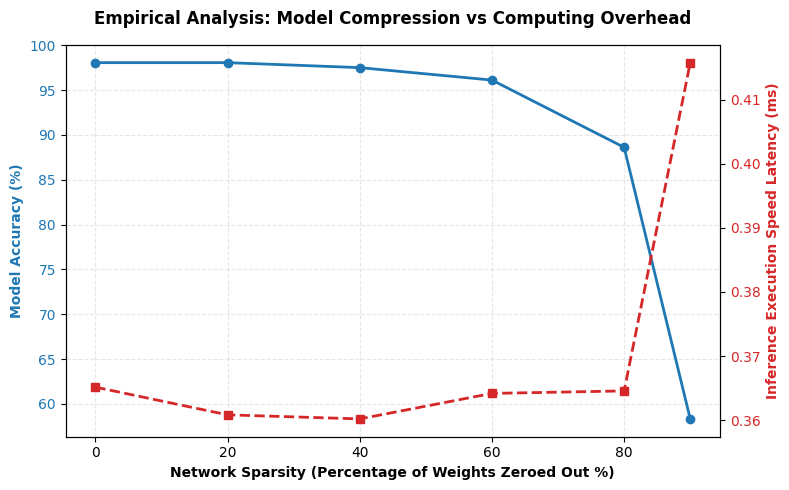

In [2]:
# 1. Dataset Preparation
digits = load_digits()
X = digits.data / 16.0  # Min-max scale pixel features to an active [0, 1] range
y = digits.target

# Convert labels into One-Hot Encoded target arrays
num_classes = 10
y_one_hot = np.zeros((y.size, num_classes))
y_one_hot[np.arange(y.size), y] = 1

# Execute an 80/20 data split split
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)

# 2. Base Model Training Protocol
print(">> Training base Multi-Layer Perceptron model...")
model = PrunableMLP(input_dim=X_train.shape[1], hidden_dim=32, output_dim=10, lr=0.1)

epochs = 500
batch_size = 32

for epoch in range(epochs):
    # Shuffle dataset indexes dynamically for every epoch
    permutation = np.random.permutation(X_train.shape[0])
    X_train_s = X_train[permutation]
    y_train_s = y_train[permutation]

    for i in range(0, X_train.shape[0], batch_size):
        X_b = X_train_s[i : i + batch_size]
        y_b = y_train_s[i : i + batch_size]
        model.forward(X_b)
        model.backward(X_b, y_b, X_b.shape[0])

# Freeze base weights prior to running pruning experiments
base_W1, base_W2 = np.copy(model.W1), np.copy(model.W2)

# 3. Running Sparsity Level Experiments
sparsity_levels = [0.0, 0.2, 0.4, 0.6, 0.8, 0.9]
accuracies, latencies = [], []

print("\n>> Evaluation Pipeline Running...")
for s in sparsity_levels:
    model.W1, model.W2 = np.copy(base_W1), np.copy(base_W2)
    model.apply_magnitude_pruning(s)

    # Evaluate baseline categorical precision
    preds = model.forward(X_test)
    accuracy = np.mean(np.argmax(preds, axis=1) == np.argmax(y_test, axis=1)) * 100
    accuracies.append(accuracy)

    # Compute high-precision mean execution timing across 100 test forward passes
    t_start = time.perf_counter()
    for _ in range(100):
        _ = model.forward(X_test)
    t_end = time.perf_counter()

    mean_ms = ((t_end - t_start) / 100) * 1000
    latencies.append(mean_ms)
    print(f"Sparsity Status: {s*100:.0f}% | Test Accuracy: {accuracy:.2f}% | Latency: {mean_ms:.4f} ms")

# 4. Generate Performance Graph Plot
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel('Network Sparsity (Percentage of Weights Zeroed Out %)', fontweight='bold')
ax1.set_ylabel('Model Accuracy (%)', color='#1f77b4', fontweight='bold')
ax1.plot([lvl * 100 for lvl in sparsity_levels], accuracies, color='#1f77b4', marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(True, linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel('Inference Execution Speed Latency (ms)', color='#d62728', fontweight='bold')
ax2.plot([lvl * 100 for lvl in sparsity_levels], latencies, color='#d62728', marker='s', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor='#d62728')

plt.title('Empirical Analysis: Model Compression vs Computing Overhead', fontsize=12, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()